# Optuna using XGBoost

In [1]:
import pandas as pd
import numpy as np
import time
import optuna
import optuna.visualization as vis

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import math

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and Shuffle Data

In [2]:
df = pd.read_csv("housing_cleaned.csv")
df = shuffle(df, random_state=42)

### Split Dataset

In [3]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Baseline Model:

Here we are building a simple baseline unturned XGRegressor model\. This same code appears at the top of most of the note books and is there to locally have a comparison value with the tuned model that is being created below it\. 

In [4]:
baseline = XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    n_jobs = -1    
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)

print("Baseline RMSE (log scale):", baseline_rmse)

Baseline RMSE (log scale): 0.16340095299614865


## Optuna with XGBoost

Unlike with Grid or Random, you do not need to set of the search method before fitting the model\. Instead Optuna works with a method called "objective"\. This method acts as a loop that repeats a number of times that is specified when the method is first called\. For each loop it picks the values for the hyperparameters, based off the limitations you set, builds your model, fits your model, tests your model, and then returns the results to be stored in the final "study" variable\. At the end, this "study" varaible will contain the inforation from every iteration and you cane extract the best hyperparameters from it as well as generate some easy and helpful graphs\.

Here we are going to fit our new Optuna model to the training data\. While doing this we will be timing how long this process takes\. The purpose of this is to give us a realitive comparison value when looking at the other model that use different tuning methods\. 

In [5]:
start = time.time()

In [6]:
 # You will want to split for your validation data outside of the Objective loop to save on the processing
 # power of the loops iterations. 
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [7]:
def objective(trial):
    
    # Suggest parameters (search space)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }

    # Build model
    model = XGBRegressor(
        **params,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=20   #faster + better stopping
    )

    # Train
    model.fit(
        X_train2,
        y_train2,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Predict + evaluate
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)

    return rmse

In [8]:
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, n_jobs=1)

[I 2026-04-25 01:27:04,116] A new study created in memory with name: no-name-d3a7f063-27cc-46d1-85ab-b2e6c04822c6
[I 2026-04-25 01:27:06,150] Trial 0 finished with value: 0.1601191195015147 and parameters: {'n_estimators': 575, 'max_depth': 5, 'learning_rate': 0.06120496945066865, 'subsample': 0.7776801196244858, 'colsample_bytree': 0.6547694825234301, 'min_child_weight': 4}. Best is trial 0 with value: 0.1601191195015147.
[I 2026-04-25 01:27:08,284] Trial 1 finished with value: 0.161084757115477 and parameters: {'n_estimators': 797, 'max_depth': 7, 'learning_rate': 0.03771038917923125, 'subsample': 0.7241530277921492, 'colsample_bytree': 0.8284566159866763, 'min_child_weight': 3}. Best is trial 0 with value: 0.1601191195015147.
[I 2026-04-25 01:27:09,694] Trial 2 finished with value: 0.160785435416546 and parameters: {'n_estimators': 755, 'max_depth': 4, 'learning_rate': 0.08590351667193831, 'subsample': 0.7843973676216708, 'colsample_bytree': 0.6830932725430383, 'min_child_weight': 3

In [9]:
end = time.time()
print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 3.92 minutes


### Extract Best Hyperparameters Values from Tuning

Now that we are finish tuning this model we can extract what the best combination of values the study was able to locate\. This does not mean that we are finished\. We now have to use these value in the creation of our final model\.

In [10]:
print("Best Params:")
print(study.best_params)

print("Best RMSE:")
print(study.best_value)

Best Params:
{'n_estimators': 619, 'max_depth': 6, 'learning_rate': 0.047754864479680935, 'subsample': 0.8015607634150367, 'colsample_bytree': 0.6069475670405354, 'min_child_weight': 1}
Best RMSE:
0.15845305951907732


### Optuna Easy / Helpful Graphs

Here is what Optuna takes another sharp departure from the usual Grid and Random Search methods\. Optuna comes with several easy to implement straight out of the box graphs\.

In [11]:
vis.plot_optimization_history(study)

In [12]:
vis.plot_param_importances(study)

In [13]:
vis.plot_slice(study, params=['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight'])

### Create Model Using Best Parameters

In [14]:
best_params = study.best_params

# Validation split again
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    early_stopping_rounds=20
)

best_model.fit(
    X_train2,
    y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6069475670405354, device=None,
             early_stopping_rounds=20, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.047754864479680935,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=619, n_jobs=None,
             num_parallel_tree=None, ...)

### Results

In [15]:
y_pred = best_model.predict(X_test)

rmse_log = mean_squared_error(y_test, y_pred, squared=False)
print("Test RMSE (log scale):", rmse_log)

Test RMSE (log scale): 0.15903044996940133


In [16]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

1.1723736448788238


### Visualize the Results 

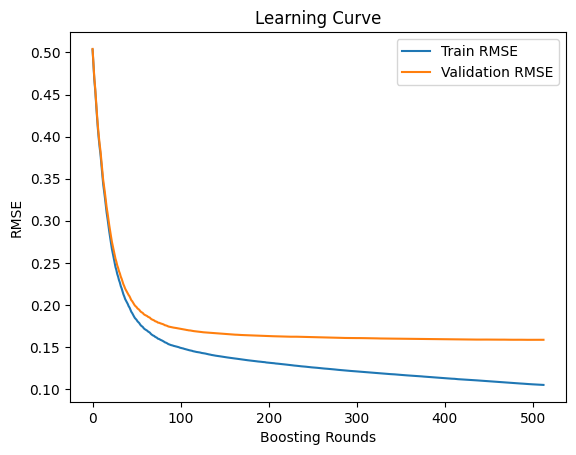

In [17]:
results = best_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure()
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

Since the Validation curve is above the training curve the model is not overfitting\. As far as underfittings, the end of the graph show as different between the lines of rougly and RMSE of 0\.07\. This is a small value, so we can determine this model is not underfitting\. 

## Tuning with Optuna and Cross Validation

Now lets do this again, but this time introduce Cross Validation\.

In [18]:
start = time.time()

In [19]:
def objective(trial):
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 550, 750),
        'max_depth': 6,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'subsample': trial.suggest_float('subsample', 0.7, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.7),
        'min_child_weight': 2,
    }

    model = XGBRegressor(
        **params,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    # 5-Fold Cross Validation
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=1
    )

    rmse = -scores.mean()
    
    return rmse

In [20]:
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-25 01:33:44,448] Trial 114 finished with value: 0.1581900129411255 and parameters: {'n_estimators': 593, 'learning_rate': 0.045059775447350264, 'subsample': 0.7478707046808196, 'colsample_bytree': 0.6045385407205071}. Best is trial 114 with value: 0.1581900129411255.
[I 2026-04-25 01:33:45,041] Trial 109 finished with value: 0.15811913623975066 and parameters: {'n_estimators': 595, 'learning_rate': 0.04507812024708763, 'subsample': 0.7476550409810688, 'colsample_bytree': 0.6177274773960554}. Best is trial 109 with value: 0.15811913623975066.
[I 2026-04-25 01:33:46,143] Trial 106 finished with value: 0.15810015988215267 and parameters: {'n_estimators': 608, 'learning_rate': 0.044778044458794686, 'subsample': 0.747446717528976, 'colsample_bytree': 0.6180949181785114}. Best is trial 106 with value: 0.15810015988215267.
[I 2026-04-25 01:33:49,551] Trial 102 finished with value: 0.1576352499674052 and parameters: {'n_estimators': 627, 'learning_rate': 0.044824496988981805, 'subsa

In [21]:
end = time.time()
print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 8.60 minutes


### Extract Best Hyperparameter Values from Tuning

In [22]:
print("Best Params:")
print(study.best_params)

print("Best RMSE:")
print(study.best_value)

Best Params:
{'n_estimators': 640, 'learning_rate': 0.04512417015907165, 'subsample': 0.7472887542985325, 'colsample_bytree': 0.6028967938079807}
Best RMSE:
0.15741999678547602


### Optuna Specific Visualizations

In [23]:
vis.plot_optimization_history(study)

In [24]:
vis.plot_param_importances(study)

In [25]:
vis.plot_slice(study, params=['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight'])

### Create Model Using Best Parameters

In [26]:
best_params = study.best_params

# Validation split again
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    early_stopping_rounds=20
)

best_model.fit(
    X_train2,
    y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6028967938079807, device=None,
             early_stopping_rounds=20, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04512417015907165,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=640, n_jobs=None,
             num_parallel_tree=None, ...)

### Results

In [27]:
y_pred = best_model.predict(X_test)

rmse_log = mean_squared_error(y_test, y_pred, squared=False)
print("Test RMSE (log scale):", rmse_log)

Test RMSE (log scale): 0.15787691280491273


In [28]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

1.1710220480172697


### Visualize the Results

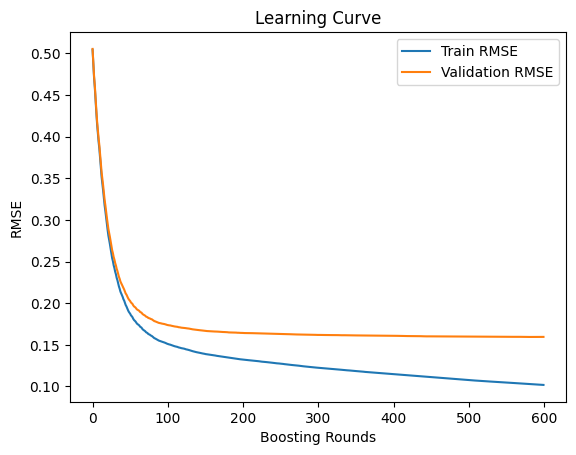

In [29]:
results = best_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure()
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=89799500-4443-401d-b5a6-3a6742d3b89e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>